# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Leemos nuestro archivo de entrada `reviews_sentiment`

Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

In [10]:
df = pd.read_csv('data/reviews_sentiment.csv', sep=';')
df.head(10)

,Review Title,Review Text,wordcount,titleSentiment,textSentiment,Star Rating,sentimentValue
0,Sin conexión,Hola desde hace algo más de un mes me pone sin...,23,negative,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,NaN,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas...,17,NaN,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,negative,1,-0.651784
5,Buena,Nada del otro mundo pero han mejorado mucho,8,positive,negative,1,-0.720443
6,De gran ayuda,"Lo malo q necesita de …,pero la app es muy buena",23,positive,negative,1,-0.726825
7,Muy buena,"Estaba más acostumbrado al otro diseño, pero e...",16,positive,negative,1,-0.736769
8,Ta to guapa.,Va de escándalo,21,positive,negative,1,-0.765284
9,Se han corregido,Han corregido muchos fallos pero el diseño es ...,13,negative,negative,1,-0.797961


## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

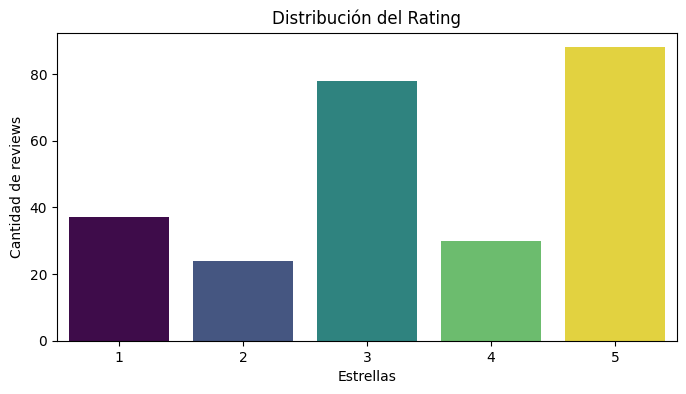

In [11]:
# Distribución del Star Rating:
plt.figure(figsize=(8, 4))
sns.countplot(x='Star Rating', data=df, hue='Star Rating', palette='viridis', legend=False)
plt.title('Distribución del Rating')
plt.xlabel('Estrellas')
plt.ylabel('Cantidad de reviews')
plt.show();

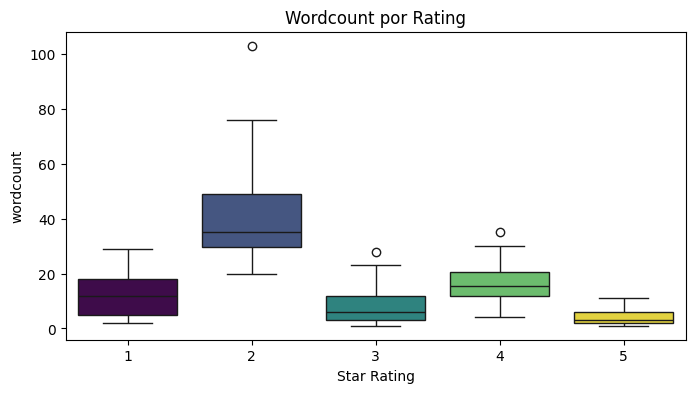

In [12]:
# Relación entre wordcount y Star Rating
plt.figure(figsize=(8, 4))
sns.boxplot(x='Star Rating', y='wordcount', data=df, hue='Star Rating', palette='viridis', legend=False)
plt.title('Wordcount por Rating')
plt.show()

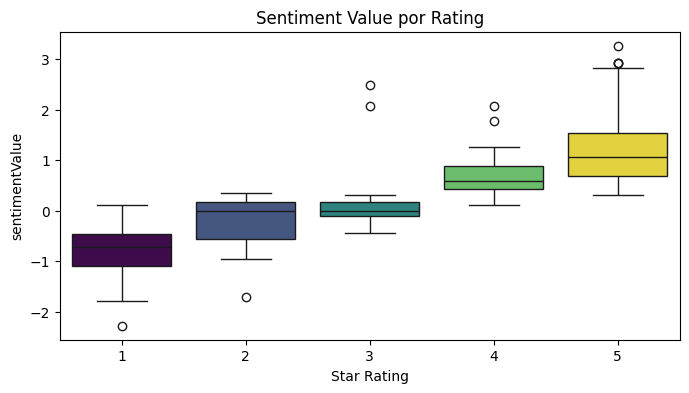

In [13]:
# Relación entre sentimentValue y Star Rating
plt.figure(figsize=(8, 4))
sns.boxplot(x='Star Rating', y='sentimentValue', data=df, hue='Star Rating', palette='viridis', legend=False)
plt.title('Sentiment Value por Rating')
plt.show()

## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Seleccionamos las features y el target:
X = df[['wordcount', 'sentimentValue']]
y = df['Star Rating']

# # Dividimos en train y test:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar (se utiliza el Min-Max Scaler)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape)
print("Test size:", X_test_scaled.shape)

Train size: (205, 2)
Test size: (52, 2)


## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Entrenar el modelo:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)

# Predicciones:
y_pred_train = knn.predict(X_train_scaled)
y_pred_test = knn.predict(X_test_scaled)

# Evaluar el error en train y test:
print("Accuracy en TRAIN:", accuracy_score(y_train, y_pred_train))
print("Accuracy en TEST: ", accuracy_score(y_test, y_pred_test))

Accuracy en TRAIN: 0.9170731707317074
Accuracy en TEST:  0.8269230769230769


In [ ]:
# Existe casi un 9% de overfit entre el modelo de test y train

## Evalúa tu modelo

              precision    recall  f1-score   support

           1       0.82      0.90      0.86        10
           2       0.40      1.00      0.57         2
           3       0.85      0.79      0.81        14
           4       1.00      0.43      0.60         7
           5       0.90      0.95      0.92        19

    accuracy                           0.83        52
   macro avg       0.79      0.81      0.75        52
weighted avg       0.86      0.83      0.82        52



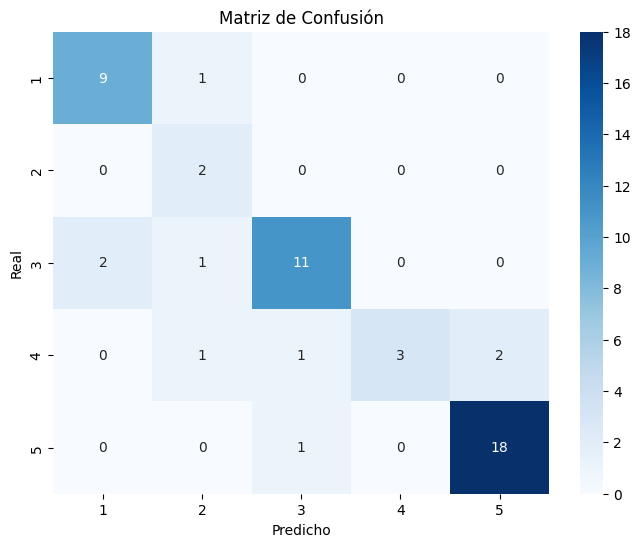

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

# Reporte completo
print(classification_report(y_test, y_pred_test))

# Matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_test), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

In [ ]:
# El modelo funciona mejor en los extremos (1 y 5 estrellas) y peor en los valores intermedios (2 y 4 estrellas), 
# lo cual es muy típico en modelos KNN con datos de sentimiento, 
# puesto que las reviews intermedias son naturalmente más ambiguas (según Claude AI)

## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? Representa todas las iteraciones en un scatterplot -> k vs accuracy

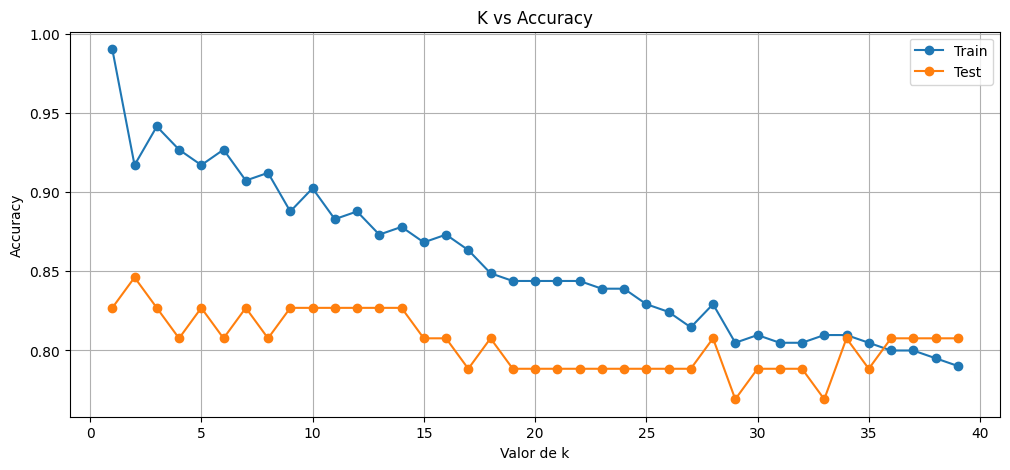

Mejor k: 2 con accuracy en test: 0.8462


In [28]:
# Probamos distintos valores de k y guardamos el accuracy
k_values = range(1, 40)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

# Scatterplot k vs accuracy
plt.figure(figsize=(12, 5))
plt.plot(k_values, train_accuracies, label='Train', marker='o')
plt.plot(k_values, test_accuracies, label='Test', marker='o')
plt.xlabel('Valor de k')
plt.ylabel('Accuracy')
plt.title('K vs Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Mejor k
best_k = k_values[test_accuracies.index(max(test_accuracies))]
print(f"Mejor k: {best_k} con accuracy en test: {max(test_accuracies):.4f}")

In [ ]:
# k=2 da el mejor accuracy en test (84.6%)
# Train accuracy cae continuamente conforme k sube
# Test accuracy se estabiliza entre 0.79-0.83 para k > 15 — el modelo generaliza de forma estable
# A partir de k=15 la línea de test baja claramente, por lo que empieza el underfitting

## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [30]:
# Reentrenamos con el mejor k
best_knn = KNeighborsClassifier(n_neighbors=2)
best_knn.fit(X_train_scaled, y_train)

# Nueva review: 5 palabras, sentimiento 1
nueva_review = pd.DataFrame([[5, 1]], columns=['wordcount', 'sentimentValue'])
nueva_review_scaled = scaler.transform(nueva_review)

prediccion = best_knn.predict(nueva_review_scaled)
print(f"Rating predicho: {prediccion[0]} estrellas")

Rating predicho: 5 estrellas
